# Plant Disease Classification

## Manipulando diretórios

In [1]:
import kagglehub

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

/home/ricardo/anaconda3/envs/plant-disease/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

base_path = Path(path)

In [3]:
child_paths = list(base_path.iterdir())
train_and_validation_path = child_paths[0]
test_path = child_paths[1]

In [4]:
train_path = train_and_validation_path / "train"
validation_path = train_and_validation_path / "valid"

In [5]:
from torchvision.datasets import ImageFolder
import torchvision.transforms as T

transforms=T.Compose([
    T.Resize(size=(128,128)),
    T.ToTensor()
])

train_dataset = ImageFolder(root=train_path, transform=transforms)
validation_dataset = ImageFolder(root=validation_path, transform=transforms)

## Exibindo informações dos datasets

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def dataset_info(dataset):
    print("[INFO] Tamanho do Dataset:", len(dataset))
    idx=np.random.randint(0, len(dataset)-1)
    img, lbl = dataset[idx]
    print("[INFO] Dimensões da imagem: ", img.shape)
    print("[INFO] Número de classes: ", len(dataset.classes))
    plt.imshow(img.permute(1,2,0))
    plt.title("Classe = {}".format(dataset.classes[lbl]))
    plt.axis(False)
    plt.show()
    plt.close()

[INFO] Tamanho do Dataset: 70295
[INFO] Dimensões da imagem:  torch.Size([3, 128, 128])
[INFO] Número de classes:  38


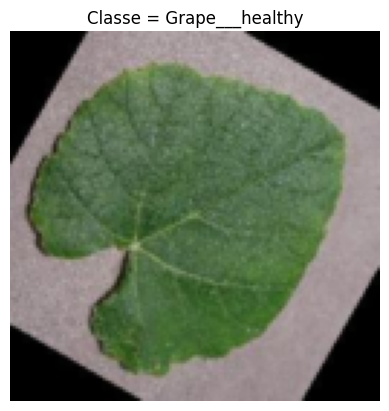

In [7]:
dataset_info(train_dataset)

[INFO] Tamanho do Dataset: 17572
[INFO] Dimensões da imagem:  torch.Size([3, 128, 128])
[INFO] Número de classes:  38


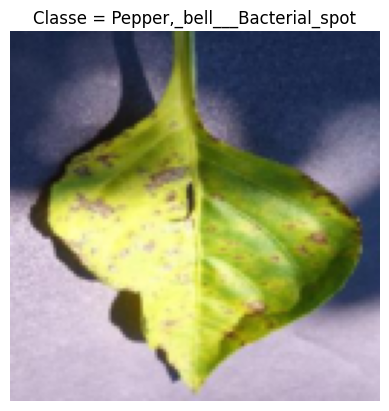

In [8]:
dataset_info(validation_dataset)

## Dataloader

In [9]:
from torch.utils.data import DataLoader
import os

nw = os.cpu_count()

train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=nw)
validation_dataloader = DataLoader(validation_dataset, batch_size=128, shuffle=False, num_workers=nw) 

## Modelo

In [10]:
from torch import nn

class Classifier(nn.Module):
    def __init__(self, in_channels, hidden_layers, num_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            #camada 1
            nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #camada 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #camada 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #camada 4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten()
        )

        self.classifier = nn.Sequential(
            nn.Linear(in_features=16384, out_features=hidden_layers),
            nn.ReLU(),
            nn.Linear(in_features=hidden_layers, out_features=num_classes)
        )

    def forward(self, X):
        X = self.feature_extractor(X)
        # print(X.shape)
        return self.classifier(X)

In [11]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("[INFO] device:", device)

[INFO] device: cuda


In [12]:
model = Classifier(in_channels=3, hidden_layers=1024, num_classes=len(train_dataset.classes)).to(device)

## Train e Test Loops

In [13]:
from tqdm import tqdm

def train_step(
        model:nn.Module, 
        train_dataloader:torch.utils.data.DataLoader, 
        loss_fn: nn.Module,
        optimizer: torch.optim,
        device:str
    ):
    model.train()

    train_loss, train_acc = 0, 0

    for batch, (X,y) in tqdm(enumerate(train_dataloader)):
        X,y = X.to(device), y.to(device)

        y_logits = model(X)
        loss = loss_fn(y_logits, y)

        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_logits)
    
    train_loss = train_loss / len(train_dataloader)
    train_acc = train_acc / len(train_dataloader)

    return train_loss, train_acc

def test_step(
        model:nn.Module, 
        test_dataloader:torch.utils.data.DataLoader, 
        loss_fn: nn.Module,
        device:str
    ):
    model.eval()

    test_loss, test_acc = 0, 0

    y_pred=[]
    y_true=[]
    with torch.inference_mode():
        for batch, (X,y) in enumerate(test_dataloader):
            X, y = X.to(device),y.to(device)

            y_logits = model(X)

            loss = loss_fn(y_logits, y)
            test_loss += loss.item()

            y_pred_class = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
            test_acc += (y_pred_class == y).sum().item() / len(y_logits)

            y_pred.append(y_pred_class)
            y_true.append(y)
    
    y_pred=torch.cat(y_pred)
    y_true=torch.cat(y_true)
    test_loss = test_loss / len(test_dataloader)
    test_acc = test_acc / len(test_dataloader)

    return test_loss, test_acc, y_pred, y_true

## Optimizer e Loss Function

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(params=model.parameters(), lr=1e-4)

## Juntando tudo e treinando o modelo

In [16]:
epochs=10

for epoch in range(epochs):
    train_loss, train_acc = train_step(
        model, 
        train_dataloader,
        loss_fn,
        optimizer,
        device
    )
    test_loss, test_acc, _, _ = test_step(
        model,
        validation_dataloader,
        loss_fn,
        device
    )

    print(f"# EPOCH: {epoch} | Train Loss: {train_loss} | Train Accuracy: {train_acc} | Validation Loss: {test_loss} | Validation Accuracy: {test_acc}.")

550it [02:43,  3.36it/s]


# EPOCH: 0 | Train Loss: 1.1552145640416578 | Train Accuracy: 0.64753520256917 | Validation Loss: 1.015880505497014 | Validation Accuracy: 0.6911986714975846.


550it [02:44,  3.35it/s]


# EPOCH: 1 | Train Loss: 0.7438251786611297 | Train Accuracy: 0.7684010622529645 | Validation Loss: 0.6662161700036107 | Validation Accuracy: 0.7925284319645733.


550it [02:44,  3.35it/s]


# EPOCH: 2 | Train Loss: 0.48558786086060785 | Train Accuracy: 0.8467922430830039 | Validation Loss: 0.4349847817388566 | Validation Accuracy: 0.8641555958132046.


550it [02:44,  3.34it/s]


# EPOCH: 3 | Train Loss: 0.33531961823051626 | Train Accuracy: 0.892729743083004 | Validation Loss: 0.35950618177193444 | Validation Accuracy: 0.888473731884058.


71it [00:21,  3.24it/s]


KeyboardInterrupt: 